<div dir="rtl" style="text-align:right">

# المحاضرة 3 — مُرسِل مرجعي

## أهداف المحاضرة
1. تفهم لماذا نبني المُرسِل **قبل** المستقبِل.
2. تحوّل نصاً (ASCII) إلى بِتات بترتيب **MSB-first**.
3. تتعرّف على **بنية الإطار** كاملة ووظيفة كل حقل (PREAMBLE / SFD / HDR / PAYLOAD / CRC).
4. تفهم فكرة **CRC** عموماً ثم تُنفّذ **CRC-16/CCITT-FALSE** وتتحقق منه بمتّجه اختبار قياسي.
5. تُولّد إشارة **CPFSK** بطور متصل، وتقرأ **مسار الطور** وعلاقته بانزياح التردد، وتفهم لماذا استمرارية الطور مهمة.
6. تبني الموجة الكاملة مع القفز الترددي والـ dead time، وتطابقها مع ملف `fhcpfsk`.

</div>


<div dir="rtl" style="text-align:right">

## 1. لماذا نبني المُرسِل أولاً؟

لاختبار المستقبِل نحتاج إشارة **نعرف إجابتها الصحيحة مسبقاً**.
لذا نبني «مُرسِلاً مرجعياً»: ندخل إليه رسائل معروفة، فيُخرج موجة نعرف كل بِت فيها. ثم نمرّر هذه الموجة على المستقبِل ونقارن مخرجه بالرسائل الأصلية. أي اختلاف = خطأ في المستقبِل.

</div>


<div dir="rtl" style="text-align:right">

## 2. من النص إلى البِتات (MSB-first — Most Significant Bit)

كل حرف ASCII يُمثَّل بـ 8 بِت. **MSB-first** يعني أن نكتب البِت الأعلى قيمةً أولاً. مثال: الحرف `'A'` قيمته 65 = `01000001`.

</div>


In [1]:
def int_to_bits(value, nbits):                               # convert an integer to a bit list
    "MSB-first bit list of an integer"                       # order: most-significant bit first
    return [(value >> i) & 1 for i in range(nbits-1, -1, -1)] # pull bit i from high to low

def text_to_bits(text):                                      # convert a whole string to bits
    bits = []                                                # output bit buffer
    for ch in text:                                          # for each character
        bits += int_to_bits(ord(ch), 8)                      # ord = ASCII code, then 8 bits per char
    return bits                                              # return the full bit stream

print("'A' =", ord('A'), "->", int_to_bits(ord('A'), 8))            # check: 'A' = 65 = 01000001
print("'HELLO123' ->", text_to_bits('HELLO123'))                   # the full text as bits
print("n bits for eight chars =", len(text_to_bits('HELLO123')))   # 8 chars x 8 = 64 bits


'A' = 65 -> [0, 1, 0, 0, 0, 0, 0, 1]
'HELLO123' -> [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1]
n bits for eight chars = 64


<div dir="rtl" style="text-align:right">

## 3. بنية الرسالة الكاملة (الإطار)

قبل أن نُرسل بيانات المستخدم، نغلّفها داخل **إطار** (frame) يحمل معها حقولاً مساعدة تُمكّن المستقبِل من العثور على الرسالة، ومزامنتها، والتأكد من سلامتها. طول الإطار الكامل **96 بِت** بالترتيب التالي:

<div dir="ltr" style="text-align:left">

```
┌────────────┬───────┬───────┬───────────────┬───────┐
│  PREAMBLE  │  SFD  │  HDR  │    PAYLOAD    │  CRC  │
│    8 b     │  5 b  │  3 b  │     64 b      │ 16 b  │
└────────────┴───────┴───────┴───────────────┴───────┘
```

</div>

**وظيفة كل حقل:**

- **PREAMBLE (التمهيد) — 8 بِت، نمط `10101010`:** أوّل ما يصل المستقبِل. النمط المتناوب يُنتج موجة نظيفة عند معدّل الرموز تُستخدم لضبط كسب المستقبِل (AGC) واستعادة توقيت الرموز (متى يبدأ كل بِت). لا يحمل بيانات.
- **SFD (بادئة بدء الإطار — Start Frame Delimiter) — 5 بِت، شيفرة Barker-5 `11101`:** «علامة» فريدة تقول للمستقبِل «انتهى التمهيد، البيانات تبدأ الآن». تُختار شيفرة Barker لأن ترابطها الذاتي حادّ (قمة واضحة، فصوص جانبية ≤ 1) فلا تلتبس ببيانات عشوائية.
- **HDR (الترويسة — Header) — 3 بِت:** رقم تسلسلي للرسالة (1..7). ولأن الرسائل تُرسَل على قنوات متناثرة، يستخدمه المستقبِل لإعادة ترتيبها ولاكتشاف رسالة ضاعت كلياً.
- **PAYLOAD (الحمولة) — 64 بِت:** البيانات الفعلية: 8 أحرف ASCII، كل حرف 8 بِتات، بترتيب MSB-first.
- **CRC (بصمة التحقق) — 16 بِت:** رقم تحقّق يُحسب من (HDR + PAYLOAD) ويكشف أي تلف أصاب الإطار في القناة. نشرح آليته في القسم التالي.

</div>


<div dir="rtl" style="text-align:right">

### لماذا Barker-5 لبادئة البدء (SFD)؟

يبحث المستقبِل عن الـ SFD بحساب **الترابط الذاتي** (autocorrelation): يمرر النمط المعروف فوق البِتات الواردة ويجمع حاصل الضرب عند كل إزاحة (lag). النمط الجيّد يعطي **قمة عالية واحدة** عند المحاذاة الصحيحة و**فصوصاً جانبية صغيرة** في بقية الإزاحات، فلا يلتبس ببيانات عشوائية. لنقارن Barker-5 `11101` بنمط بلا هذه الخاصية (كله آحاد `11111`) — بعد تخطيط `1- → 0، 1+ → 1`.

</div>


<div dir="rtl" style="text-align:right">

### كيف يعمل الترابط الذاتي؟ (مثال محسوب خطوة بخطوة)

**1) نبدأ من النمط الثنائي**

<div dir="ltr" style="text-align:left">

```
barker = [1, 1, 1, 0, 1]
```

</div>

يحوّله الكود إلى ‎±1‎:

- `1+ → 1`
- `1- → 0`

فيصبح x = [+1, +1, +1, -1, +1]. هذا التحويل مهم: نحن **لا** نُرابِط قيم `0/1` الأصلية، بل نسخةَ ‎±1‎.

**2) ما معنى الترابط الذاتي؟**

نأخذ المتتالية ونُمرر نسخةً منها فوق نفسها؛ وعند كل إزاحة (lag) نضرب العناصر المتراكبة ونجمع الحواصل. عند الإزاحة صفر (محاذاة تامّة):

<div dir="ltr" style="text-align:left">

```
x        :  +1  +1  +1  -1  +1
copy (→0):  +1  +1  +1  -1  +1
                --  --  --  --
overlap  :  the 5 overlapping pairs
```

</div>

<div dir="ltr" style="text-align:left">

$$ R[0] = (+1)(+1)+(+1)(+1)+(+1)(+1)+(-1)(-1)+(+1)(+1) = 5 $$

</div>

وهذا **دائماً** يساوي N (طول المتتالية) لأن كل حدٍّ هو <span dir="ltr">(±1)<sup>2</sup> = 1</span>. فمركز الترابط هو القمة: R[0]=5.

**3) نُزيح بمقدار عيّنة واحدة**

<div dir="ltr" style="text-align:left">

```
x        :  +1  +1  +1  -1  +1
copy (→1):      +1  +1  +1  -1  +1
                --  --  --  --
overlap  :  the 4 overlapping pairs
```

</div>

الأزواج الأربعة المتراكبة تُضرب وتُجمع:

<div dir="ltr" style="text-align:left">

$$ R[1] = (1)(1) + (1)(1) + (1)(-1) + (-1)(1) = 1 + 1 - 1 - 1 = 0 $$

</div>

إذن R[1]=0 — وهذه هي **خاصية Barker** المهمّة: الفصوص الجانبية تقترب من الصفر، فتبرز القمّة وحدها.

> **للمقارنة**، لو كان النمط «كله آحاد» x=[+1,+1,+1,+1,+1]، فعند الإزاحة 1 تتراكب أربعة أزواج كلّها <span dir="ltr">(+1)(+1)</span>، فيكون R[1] = 1+1+1+1 = 4 — فصٌّ جانبيٌّ كبير قريب من القمّة، ولذلك يصعب تمييز بداية الإطار. الكود التالي يرسم هذا الفرق كاملاً عند كل الإزاحات.

</div>


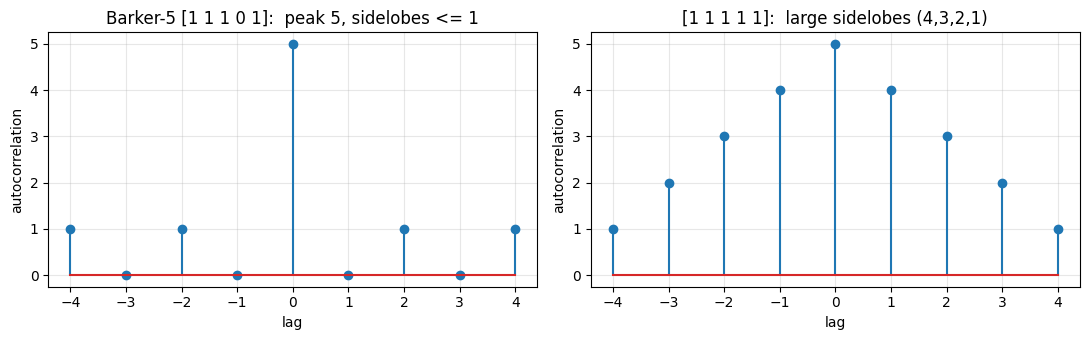

In [2]:
import numpy as np                       
import matplotlib.pyplot as plt     

def autocorr(seq):                                    # autocorrelation of a +/-1 mapped pattern
    x = np.array([1.0 if b else -1.0 for b in seq])   # map 0 -> -1, 1 -> +1
    return np.correlate(x, x, mode='full')            # correlation value at every lag

barker = [1,1,1,0,1]                                  # Barker-5 (our SFD)
plain  = [1,1,1,1,1]                                  # a pattern with no Barker property (all ones)
lags = np.arange(-4, 5)                               # lag axis (-4 .. +4)

plt.figure(figsize=(11,3.5))                          # figure size
plt.subplot(1,2,1)                                    # left panel: Barker-5
plt.stem(lags, autocorr(barker))                      # its autocorrelation
plt.title("Barker-5 [1 1 1 0 1]:  peak 5, sidelobes <= 1")  # one sharp, unambiguous peak
plt.xlabel("lag"); plt.ylabel("autocorrelation"); plt.grid(alpha=0.3)
plt.subplot(1,2,2)                                    # right panel: all-ones
plt.stem(lags, autocorr(plain))                       # its autocorrelation
plt.title("[1 1 1 1 1]:  large sidelobes (4,3,2,1)")  # broad, ambiguous, no clear edge
plt.xlabel("lag"); plt.ylabel("autocorrelation"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()                        # show


<div dir="rtl" style="text-align:right">

قمة Barker-5 تساوي 5 (طول النمط) وكل فصوصها الجانبية <span dir="ltr">≤ 1</span>، فتبرز القمة بوضوح ويسهل قفلها بعتبة. أما النمط «كله آحاد» فترابطه **مثلث** (5، 4، 3، 2، 1) بفصوص جانبية كبيرة قريبة من القمة، فيصعب تحديد بداية الإطار بدقة. لهذا نختار شيفرة Barker علامةً للبدء.

</div>


<div dir="rtl" style="text-align:right">

## 4. الـ CRC — التحقق من سلامة البيانات

### ما هو الـ CRC ولماذا؟
الـ **CRC** (اختصار *Cyclic Redundancy Check* — التحقق الدوري بالتكرار) رقمٌ قصير يُحسب من البيانات ويُرسَل معها كـ«بصمة». يعيد المستقبِل حسابه على ما استقبله ويقارنه بالمُرسَل؛ أيّ اختلاف يعني أن القناة أفسدت بِتاً أو أكثر. إنه **يكتشف** الأخطاء (لا يصحّحها)، لكنه رخيص جداً وقويّ في كشف الأخطاء.

### ما هو GF(2)؟
GF(2) (حقل غالوا ذو العنصرين) هو أبسط حقل رياضي: عنصراه هما `0` و`1` فقط، وكل العمليات تُجرى **بباقي القسمة على 2** (بلا حمل carry). فيه:

- **الجمع = الطرح = XOR**: <span dir="ltr">0⊕0=0, 1⊕1=0, 0⊕1=1</span> (لأن <span dir="ltr">1+1=2≡0</span>).
- **الضرب = AND**: <span dir="ltr">1·1=1</span>، وما عداه <span dir="ltr">0</span>.

نستخدمه لأن البِتات نفسها قيمها `0/1`؛ فتصير حسابات الأكواد سلسلةَ عمليات XOR بسيطة وسريعة على العتاد.

### كيف يُحسب؟ (الفكرة الرياضية)
نعامل بِتات الرسالة كمعاملات على GF(2):

<div dir="ltr" style="text-align:left">

$$ M(x) = m_{k-1}x^{k-1} + \dots + m_1 x + m_0 $$

</div>

نختار  مولِّد G(x) من الدرجة r، ثم نحسب:

<div dir="ltr" style="text-align:left">

$$ \text{CRC} \;=\; R(x) \;=\; \big[\, M(x)\cdot x^{r} \,\big] \bmod G(x) $$

</div>

أي: نُزيح الرسالة r خانة (نُلحِق r أصفاراً)، ونقسمها على G(x) **قسمةً على 2** (كل طرح = XOR)، والباقي R(x) هو الـ CRC. عندئذٍ تصبح الكلمة المُرسَلة T(x) = M(x)·x<sup>r</sup> + R(x) **قابلة للقسمة على G(x) تماماً**؛ فعند الاستقبال نقسم الكلمة المُستقبَلة على G(x): باقٍ = صفر ⇐ سليمة، باقٍ ≠ صفر ⇐ خطأ.

### مثال بسيط بالقسمة المطوّلة
لنأخذ رسالة قصيرة M = 1101 ومولِّداً G = 1011 (أي x<sup>3</sup>+x+1، درجته r=3). نُلحِق 3 أصفار (M·x<sup>3</sup> = 1101000) ونقسم على G بالـ **XOR** ؛ في كل صف نُجري XOR مع G عندما يكون البِت الأعلى الحالي = 1:

<div dir="ltr" style="text-align:left">

```
 1 1 0 1 0 0 0    <- M . x^3  (dividend)
 1 0 1 1          <- G  (XOR, aligned at bit 0)
 --------------
 0 1 1 0 0 0 0
   1 0 1 1        <- G  (aligned at bit 1)
   ------------
 0 0 1 1 1 0 0
     1 0 1 1      <- G  (aligned at bit 2)
     ----------
 0 0 0 1 0 1 0
       1 0 1 1    <- G  (aligned at bit 3)
       --------
 0 0 0 0 0 0 1    <- remainder R = 001  (the CRC)
```

</div>

إذن الـ CRC = `001`، والكلمة المُرسَلة <span dir="ltr">= 1101001</span>. نتحقق بالكود التالي أنها قابلة للقسمة على G (باقٍ = 0)، وأن قلب بِت واحد يجعل الباقي غير صفري (فيُكتشف الخطأ):

</div>


In [3]:
def poly_mod(bits, gen):                        # remainder of GF(2) polynomial division: bits mod gen
    reg = list(bits)                            # work on a copy of the bits
    r = len(gen) - 1                            # degree of the generator
    for i in range(len(bits) - r):              # walk down to the last r bits
        if reg[i]:                              # if the current leading bit is 1
            for j in range(len(gen)):           # XOR the generator into place
                reg[i+j] ^= gen[j]              # GF(2) subtraction = XOR
    return reg[-r:]                             # the last r bits are the remainder

M = [1,1,0,1]                                   # message   1101
G = [1,0,1,1]                                   # generator 1011  = x^3 + x + 1
r = len(G) - 1                                  # r = 3  (CRC length in bits)
R = poly_mod(M + [0]*r, G)                      # CRC = (M . x^r) mod G
print("message   M =", M)                       #
print("generator G =", G, " (x^3 + x + 1)")     #
print("CRC       R =", R)                        # -> [0, 0, 1]

codeword = M + R                                # transmitted word = M . x^r + R
print("codeword =", codeword)                    # 1101001
print("codeword mod G =", poly_mod(codeword, G), "(all zeros = valid)")  # -> [0, 0, 0]

bad = codeword.copy(); bad[2] ^= 1              # flip one bit to simulate a channel error
print("one flipped bit -> mod G =", poly_mod(bad, G), "(non-zero = error caught)")


message   M = [1, 1, 0, 1]
generator G = [1, 0, 1, 1]  (x^3 + x + 1)
CRC       R = [0, 0, 1]
codeword = [1, 1, 0, 1, 0, 0, 1]
codeword mod G = [0, 0, 0] (all zeros = valid)
one flipped bit -> mod G = [1, 1, 0] (non-zero = error caught)


<div dir="rtl" style="text-align:right">

### ما الذي نستخدمه في مُرسِلنا؟
نستخدم النكهة القياسية **CRC-16/CCITT-FALSE** — بنفس فكرة المثال أعلاه لكن بمولِّد من 16 بِت — بمعاملاتها:

| المعامل | القيمة |
|---|---|
| Polynomial | `0x1021` |
| Init | `0xFFFF` |
| Input reflected | لا |
| Output reflected | لا |
| Final XOR | لا |

</div>


In [4]:
def crc16_ccitt_false(bits):                    # compute CRC-16/CCITT-FALSE over a bit stream
    "bit-wise CRC-16/CCITT-FALSE (the covered HDR+PAYLOAD is 67 bits, not byte-aligned)"
    crc = 0xFFFF                                 # Init: fill the 16-bit register with ones (FALSE flavor)
    for b in bits:                              # process each bit in order (MSB-first)
        msb = (crc >> 15) & 1                   # the top bit leaving the register
        crc = (crc << 1) & 0xFFFF               # shift left, keep 16 bits
        if msb ^ (int(b) & 1):                  # if the outgoing bit differs from the input bit (XOR = 1)
            crc ^= 0x1021                       # subtract the generator G(x) via XOR
    return crc                                  # the remainder = the CRC (16 bits)

# standard test vector: the 72 bits of "123456789" must give 0x29B1
tv = []                                         # standard test vector to validate the implementation
for byte in b"123456789":                       # for each byte of the standard string
    tv += [(byte >> i) & 1 for i in range(7, -1, -1)]  # convert it to 8 MSB-first bits
test = crc16_ccitt_false(tv)                    # run it through our function
print("CRC('123456789') =", hex(test), "-> correct?", test == 0x29B1)  # must equal 0x29B1


CRC('123456789') = 0x29b1 -> correct? True


<div dir="rtl" style="text-align:right">

## 5. تجميع الإطار

نضع الحقول بالترتيب الذي رأيناه (PREAMBLE + SFD + HDR + PAYLOAD + CRC)، ونحسب الـ CRC على (HDR + PAYLOAD) قبل إلحاقه، فيكتمل الإطار عند 96 بِت.

</div>


In [5]:
PREAMBLE = [1,0]*4               # 8 bits     # alternating preamble 10101010
SFD      = [1,1,1,0,1]           # Barker-5   # start-of-frame marker

def build_frame_bits(message, seq):                    # build a 96-bit frame for a message + seq number
    assert len(message) == 8                            # message must be exactly 8 chars
    hdr = int_to_bits(seq, 3)                           # 3-bit sequence number (the header)
    payload = text_to_bits(message)                     # payload: 64 bits from the message text
    crc = crc16_ccitt_false(hdr + payload)              # CRC over HDR+PAYLOAD (67 bits)
    crc_bits = int_to_bits(crc, 16)                     # convert the CRC to 16 MSB-first bits
    frame = PREAMBLE + SFD + hdr + payload + crc_bits   # concatenate all fields in order
    assert len(frame) == 96                             # the total length must be 96 bits
    return frame                                        # return the complete frame

frame = build_frame_bits('HELLO123', 1)                 # example: build the first message's frame
print("frame length =", len(frame))                     # should be 96
print("PREAMBLE:", frame[:8])                            # first 8 bits (preamble)
print("SFD     :", frame[8:13])                          # bits 9..13 (start delimiter)
print("HDR     :", frame[13:16], "= seq", int("".join(map(str,frame[13:16])),2))  # header as a number

# check: matches the reference library
import fhcpfsk as fh                                     # the reference library (answer key)
print("matches fhcpfsk?", frame == fh.build_frame_bits('HELLO123', 1))  # must match exactly


frame length = 96
PREAMBLE: [1, 0, 1, 0, 1, 0, 1, 0]
SFD     : [1, 1, 1, 0, 1]
HDR     : [0, 0, 1] = seq 1


matches fhcpfsk? True


<div dir="rtl" style="text-align:right">

## 6. تعديل CPFSK بطور متصل

### 1) FSK العادي: ترددان اثنان
نمثّل كل بِت بأحد ترددين حول الحامل f<sub>c</sub> بانزياحٍ ثابت قدره <span dir="ltr">4 MHz</span> — نغمة أعلى للبِت `1` وأخفض للبِت `0`:

<div dir="ltr" style="text-align:center">

$$ f_1 = f_c + \Delta f, \qquad f_0 = f_c - \Delta f $$

</div>

**مثال عددي:** لو كان الحامل <span dir="ltr">100 MHz</span>، صار البِت `1` عند <span dir="ltr">104 MHz</span> والبِت `0` عند <span dir="ltr">96 MHz</span>.

### 2) المشكلة: النغمات المُولّدة باستقلال تُحدث قفزات طور
لو ولّدنا نغمة كل بِت بمذبذب مستقل يبدأ من طوره الخاص، فقد تظهر **قفزات (discontinuities) في الطور** عند حدود البِتات:

<div dir="ltr" style="text-align:left">

```
        bit 1        bit 0        bit 1
       /\/\/\/\     /\/\/\/\     /\/\/\/\
------/--------\---/--------\---/--------\------
               ^            ^
            phase        phase
             jump         jump
```

</div>

هذه القفزات تُبدّد الطاقة في فصوص جانبية طيفية (سنراها في قسم «طور متصل مقابل غير متصل» لاحقاً). لذا يشترط **CPFSK** ألّا نُعيد بدء الطور عند كل بِت.

### 3) الحل: مُراكِم طور (phase accumulator)
نتخيّل أن المُرسِل يملك **مُراكِم طور**؛ التردد اللحظي يحدّد سرعة تغيّره. والعلاقة الأساسية أن **الطور تكامل التردد** (وبالعكس، التردد هو ميل الطور):

<div dir="ltr" style="text-align:center">

$$ \phi(t) = 2\pi \int_0^t f_{inst}(\tau)\, d\tau \qquad\Longleftrightarrow\qquad f_{inst}(t) = \frac{1}{2\pi}\,\frac{d\phi(t)}{dt} $$

</div>

### 4) التردد اللحظي
نكتب التردد اللحظي كحاملٍ يزيده أو ينقصه انزياحٌ حسب إشارة البِت s (قيمتها <span dir="ltr">+1</span> للبِت `1` و <span dir="ltr">−1</span> للبِت `0`):

<div dir="ltr" style="text-align:center">

$$ f_{inst}(t) = f_c + s(t)\,\Delta f, \qquad s(t) = \begin{cases} +1 & \text{بِت } 1 \\ -1 & \text{بِت } 0 \end{cases} $$

</div>

حتى الآن هذا FSK عادي؛ والجديد أننا نُكامل هذا التردد **باستمرار** بلا إعادة بدء.

### 5) فصل الحامل: الطور الزائد θ
نُكامل التردد الكامل ثم نفصل حدّيه: طور الحامل، وطور التعديل الإضافي الذي نسمّيه **الطور الزائد** θ:

<div dir="ltr" style="text-align:center">

$$ \phi(t) = \underbrace{2\pi f_c t}_{\text{الحامل}} + \underbrace{2\pi\,\Delta f \int_0^t s(\tau)\, d\tau}_{\text{التعديل}} $$

$$ \theta(t) = \phi(t) - 2\pi f_c t = 2\pi\,\Delta f \int_0^t s(\tau)\, d\tau $$

</div>

وهذه هي المعادلة التي نُنفّذ بها CPFSK عملياً.

### 6) ماذا يحدث خلال بِت واحد؟
داخل بِت مدّته T<sub>b</sub> تكون s ثابتة، فالتكامل خطّي: يرتفع الطور الزائد للبِت `1` وينخفض للبِت `0`:

<div dir="ltr" style="text-align:center">

$$ \text{بِت } 1:\quad \theta(t) = +2\pi\,\Delta f\, t \ (\uparrow) \qquad\qquad \text{بِت } 0:\quad \theta(t) = -2\pi\,\Delta f\, t \ (\downarrow) $$

</div>

### 7) لماذا يتغيّر الطور ±π لكل بِت؟
عند نهاية البِت (عند T<sub>b</sub>) يكون التغيّر الكلي مساوياً لـ <span dir="ltr">±2π·Δf·T<sub>b</sub></span>. ومؤشّر التعديل في نظامنا h قيمته 1، أي أن Δf·T<sub>b</sub> يساوي النصف؛ فنحصل على:

<div dir="ltr" style="text-align:center">

$$ \Delta\theta = \pm\, 2\pi\,\Delta f\, T_b = \pm\, 2\pi\left(\tfrac{1}{2}\right) = \pm\, \pi $$

</div>

أي أن كل `1` يرفع الطور الزائد بمقدار <span dir="ltr">+180°</span>، وكل `0` يخفضه <span dir="ltr">−180°</span>. لكن أولاً لنرَ النغمتين مباشرةً:

</div>


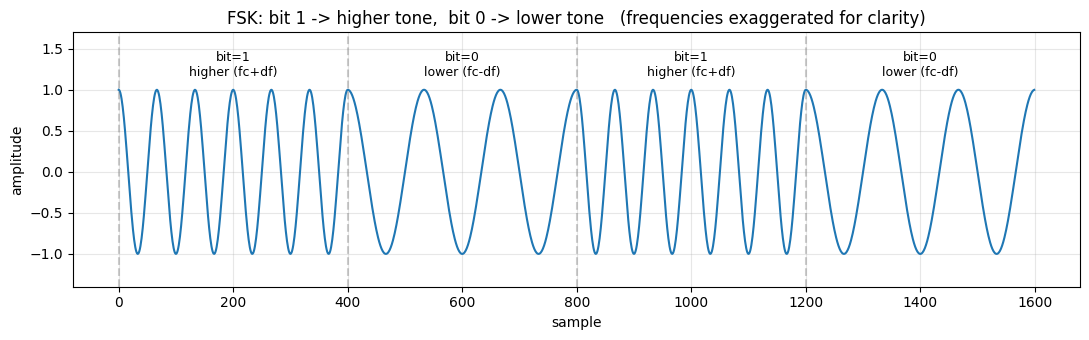

In [6]:
import numpy as np                                    # numeric library
import matplotlib.pyplot as plt                       # plotting library

# illustration only: exaggerated frequencies so the two tones are clearly visible
cyc_hi, cyc_lo = 6, 3                                  # cycles per bit for '1' (higher) and '0' (lower)
bits_fsk = [1, 0, 1, 0]                                # demo bit stream
nper = 400                                             # samples per bit (smooth curve)
wave_fsk = []                                          # waveform buffer
for b in bits_fsk:                                     # for each bit
    cyc = cyc_hi if b else cyc_lo                       # 1 -> more cycles/bit, 0 -> fewer
    tt = np.linspace(0, 1, nper, endpoint=False)        # normalized time within the bit
    wave_fsk.append(np.cos(2*np.pi*cyc*tt))             # a tone whose frequency encodes the bit
wave_fsk = np.concatenate(wave_fsk)                     # join all bits into one waveform
x = np.arange(len(wave_fsk))                            # sample index (x-axis)

plt.figure(figsize=(11,3.5))                           # figure size
plt.plot(x, wave_fsk)                                  # plot the FSK waveform
for k, b in enumerate(bits_fsk):                       # annotate each bit
    plt.axvline(k*nper, color='gray', ls='--', alpha=0.4)          # bit boundary
    plt.text(k*nper + nper/2, 1.30,                                 # label above each bit
             f"bit={b}\n{'higher (fc+df)' if b else 'lower (fc-df)'}",
             ha='center', va='center', fontsize=9)
plt.title("FSK: bit 1 -> higher tone,  bit 0 -> lower tone   (frequencies exaggerated for clarity)")
plt.xlabel("sample"); plt.ylabel("amplitude"); plt.ylim(-1.4, 1.7)  # axes
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()    # grid + show


<div dir="rtl" style="text-align:right">

### مسار الطور لبِت واحد
والآن نرسم **مسار الطور الزائد** لبِت `1` واحد وبِت `0` واحد؛ لاحظ أنه يصل إلى <span dir="ltr">± 180°</span> عند نهاية البِت (وميلُه هو التردد).

</div>


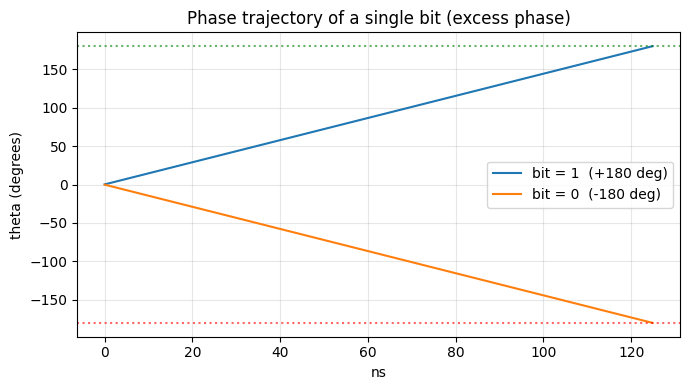

In [7]:
import numpy as np                                     # numeric library
import matplotlib.pyplot as plt                        # plotting library

Rb, Tb, SPS, FS = fh.Rb, fh.Tb, fh.SPS, fh.FS          # system constants from the reference lib
DEV = Rb/2                                             # frequency deviation +/-4 MHz (gives h = 1)

def excess_phase(bits, dev=DEV, sps=SPS, fs=FS):       # accumulate the excess phase theta(t)
    signs = np.array([1.0 if b else -1.0 for b in bits])  # 1 -> +1 (rises), 0 -> -1 (falls)
    f_excess = dev*np.repeat(signs, sps)               # excess frequency per sample: +/-df
    return 2*np.pi*np.cumsum(f_excess)/fs              # theta = 2*pi * (cumulative integral of excess freq)

t1 = np.arange(SPS)/FS*1e9                             # time axis for one bit (ns)
th_one  = np.degrees(excess_phase([1]))               # phase trajectory for a '1' bit, in degrees
th_zero = np.degrees(excess_phase([0]))               # phase trajectory for a '0' bit, in degrees

plt.figure(figsize=(7,4))                             # figure size
plt.plot(t1, th_one,  label="bit = 1  (+180 deg)")    # phase (degrees) for a 1 bit
plt.plot(t1, th_zero, label="bit = 0  (-180 deg)")    # and for a 0 bit
plt.axhline( 180, color='g', ls=':', alpha=0.6)       # +180 deg reference line
plt.axhline(-180, color='r', ls=':', alpha=0.6)       # -180 deg reference line
plt.title("Phase trajectory of a single bit (excess phase)")  # title
plt.xlabel("ns"); plt.ylabel("theta (degrees)")       # axis labels
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()  # grid + legend + show


<div dir="rtl" style="text-align:right">

### مسار الطور الكامل

تذكّر أن **ميل** مسار الطور هو التردد نفسه (ميل موجب لبِت `1` = تردد أعلى، وسالب لبِت `0` = تردد أخفض). الآن نرسم المسار الكامل لسلسلة بِتات.

</div>


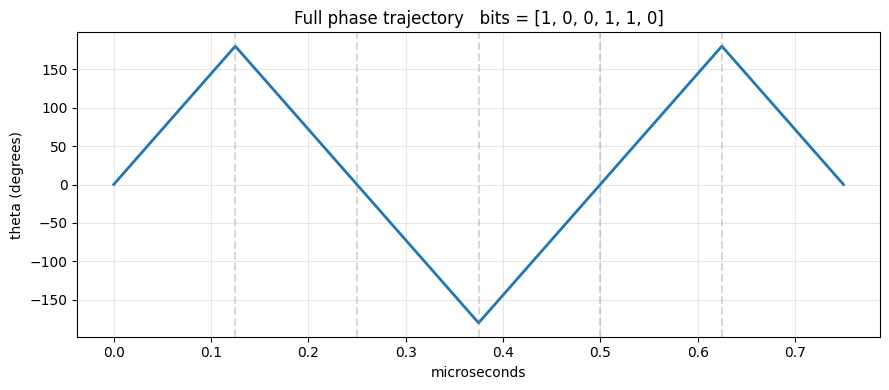

In [8]:
def cpfsk_modulate(bits, fc, fs=FS, sps=SPS, dev=DEV):  # continuous-phase FSK generator
    signs = np.array([1.0 if b else -1.0 for b in bits])  # 1 -> +dev (upper tone), 0 -> -dev
    f_inst = fc + dev*np.repeat(signs, sps)             # instantaneous frequency per sample
    phase = 2*np.pi*np.cumsum(f_inst)/fs                # phase = cumulative integral (continuous phase)
    return np.cos(phase)                                # the resulting real signal

bits_demo = [1,0,0,1,1,0]                               # demo bit stream
th = np.degrees(excess_phase(bits_demo))               # full excess-phase trajectory, in degrees
t  = np.arange(len(th))/FS*1e6                          # time in microseconds

plt.figure(figsize=(9,4))                              # figure size
plt.plot(t, th, lw=2)                                  # plot theta (degrees) across all bits
for k in range(1, len(bits_demo)):                     # at each bit boundary
    plt.axvline(k*Tb*1e6, color='gray', ls='--', alpha=0.3)  # vertical separator
plt.title("Full phase trajectory   bits = %s" % bits_demo)   # title
plt.xlabel("microseconds"); plt.ylabel("theta (degrees)")    # axis labels
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()    # grid + show


<div dir="rtl" style="text-align:right">

### طور متصل مقابل طور غير متصل — لماذا الاستمرارية مهمة؟

لنُبرز الفرق نأخذ أبسط تدفّق ممكن: **كلّه أصفار**. في الحالة المتصلة نُراكم الطور، فينخفض θ خطياً بلا انقطاع (نغمة واحدة نظيفة عند f<sub>c</sub> - Δf). أما لو «صفّرنا» الطور المتراكم عند بداية كل بِت (كأننا نُولّد كل نغمة بمذبذب مستقل بلا ذاكرة)، فسيقفز الطور فجأة عند كل حدّ بِت. هذه القفزات تُنتج فصوصاً جانبية طيفية (spectral splatter) تتسرّب إلى القنوات المجاورة — ولهذا يُصرّ النظام على CPFSK.

</div>


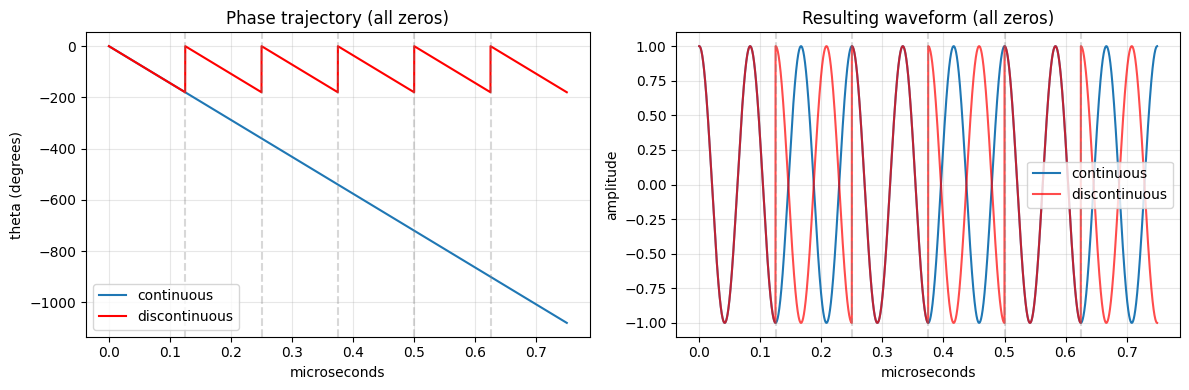

In [9]:
bits0 = [0]*6                                          # an all-zeros bit stream
fc_demo = 16e6                                         # low carrier, for visual clarity only (= 2*Rb)

th_cont = np.degrees(excess_phase(bits0))              # continuous phase: accumulates, falls linearly
th_disc = np.degrees(np.concatenate([excess_phase([0]) for _ in bits0]))  # discontinuous: restarts each bit

t = np.arange(len(th_cont))/FS*1e6                     # time axis (microseconds)
fig, ax = plt.subplots(1, 2, figsize=(12,4))          # two panels side by side

ax[0].plot(t, th_cont, label="continuous")            # continuous phase trajectory (smooth ramp)
ax[0].plot(t, th_disc, 'r', label="discontinuous")    # discontinuous (sawtooth)
for k in range(1, len(bits0)):                        # at each bit boundary
    ax[0].axvline(k*Tb*1e6, color='gray', ls='--', alpha=0.3)  # separator
ax[0].set_title("Phase trajectory (all zeros)")       # title
ax[0].set_xlabel("microseconds"); ax[0].set_ylabel("theta (degrees)")  # axes
ax[0].grid(alpha=0.3); ax[0].legend()                 # grid + legend

n = np.arange(len(th_cont))                            # sample indices
s_cont = np.cos(2*np.pi*fc_demo*n/FS + np.radians(th_cont))  # waveform from continuous phase (clean tone)
s_disc = np.cos(2*np.pi*fc_demo*n/FS + np.radians(th_disc))  # waveform from reset phase (has jumps)
ax[1].plot(t, s_cont, label="continuous")             # continuous waveform
ax[1].plot(t, s_disc, 'r', alpha=0.7, label="discontinuous")  # discontinuous waveform
for k in range(1, len(bits0)):                        # bit boundaries
    ax[1].axvline(k*Tb*1e6, color='gray', ls='--', alpha=0.3)
ax[1].set_title("Resulting waveform (all zeros)")     # title
ax[1].set_xlabel("microseconds"); ax[1].set_ylabel("amplitude")  # axes
ax[1].grid(alpha=0.3); ax[1].legend()                 # grid + legend
plt.tight_layout(); plt.show()                        # show


<div dir="rtl" style="text-align:right">

لاحظ في اللوحة اليسرى: المسار المتصل خطٌّ نازل ناعم، بينما غير المتصل «سنّ منشار» يقفز <span dir="ltr">+π</span> عند كل حدّ بِت. وفي اللوحة اليمنى تظهر هذه القفزات ككَسرات مفاجئة في الموجة — وهي مصدر التسرّب الطيفي الذي نتجنّبه بالطور المتصل.

</div>


<div dir="rtl" style="text-align:right">

## 7. القفز الترددي وبناء الموجة الكاملة

نضع كل إطار على قناة من مجموعة القفز، ونصل الإطارات متتالية (بلا فجوة بينها حسب المواصفات)، ونحيط الكل بزمن صامت (dead time) في الطرفين.

</div>


samples: 688128  | duration: 84.00 us


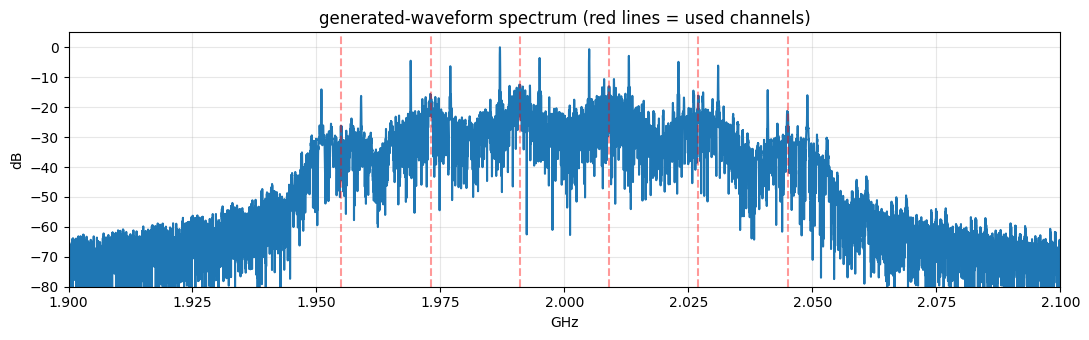

In [ ]:
def transmit(messages, channels, seed=0, dead_before_us=6, dead_after_us=6):  # build the full waveform
    hs = fh.hop_set()                                   # the six channel frequencies
    dead_before = int(round(dead_before_us*1e-6*FS))    # silent samples before the first hop
    dead_after  = int(round(dead_after_us*1e-6*FS))     # silent samples after the last hop
    parts=[np.zeros(dead_before)]; starts=[]; pos=dead_before  # start with dead time
    for i,msg in enumerate(messages):                   # for each message
        bits = build_frame_bits(msg, i+1)               # build its frame (sequence number i+1)
        parts.append(cpfsk_modulate(bits, hs[channels[i]]))  # CPFSK-modulate it on its channel
        starts.append(pos); pos += len(bits)*SPS        # record its start and advance the pointer
    parts.append(np.zeros(dead_after))                  # append trailing dead time
    return np.concatenate(parts), starts                # join all parts into one waveform

messages = ['HELLO123','RADIO_RX','FH-CPFSK','DIRECT!!','SAMPLING','LECTURE0']  # 6 messages
channels = [0,4,3,2,1,5]                                 # channel for each message
wave, starts = transmit(messages, channels)             # generate the full waveform
print("samples:", len(wave), " | duration:", f"{len(wave)/FS*1e6:.2f} us")  # length and duration

# spectrum to confirm the used channels appear
S = 20*np.log10(np.abs(np.fft.rfft(wave*np.hanning(len(wave))))+1e-9)  # power spectrum (dB)
f = np.fft.rfftfreq(len(wave), 1/FS)                    # frequency axis
plt.figure(figsize=(11,3.5))                            # figure size
plt.plot(f/1e9, S-S.max());                             # plot spectrum normalized to its peak
for c_ in set(channels): plt.axvline(fh.hop_set()[c_]/1e9, color='r', ls='--', alpha=0.4)  # used channels
plt.xlim(1.90,2.10); plt.ylim(-80,5); plt.grid(alpha=0.3)  # axis limits and grid
plt.xlabel("GHz"); plt.ylabel("dB"); plt.title("generated-waveform spectrum (red lines = used channels)")  # labels
plt.tight_layout(); plt.show()                          # show


<div dir="rtl" style="text-align:right">

### الموجة في المجال الزمني

نعرض الموجة الحقيقية الكاملة عبر الزمن: يحيط زمنٌ صامت (dead time) بستة إطارات متتالية بلا فجوات بينها، والخطوط الحمراء تُعلّم بداية كل إطار (قفزة). ثم نُكبّر نافذةً قصيرة جداً في أول إطار لتظهر جِيبية الحامل عالي التردد.

</div>


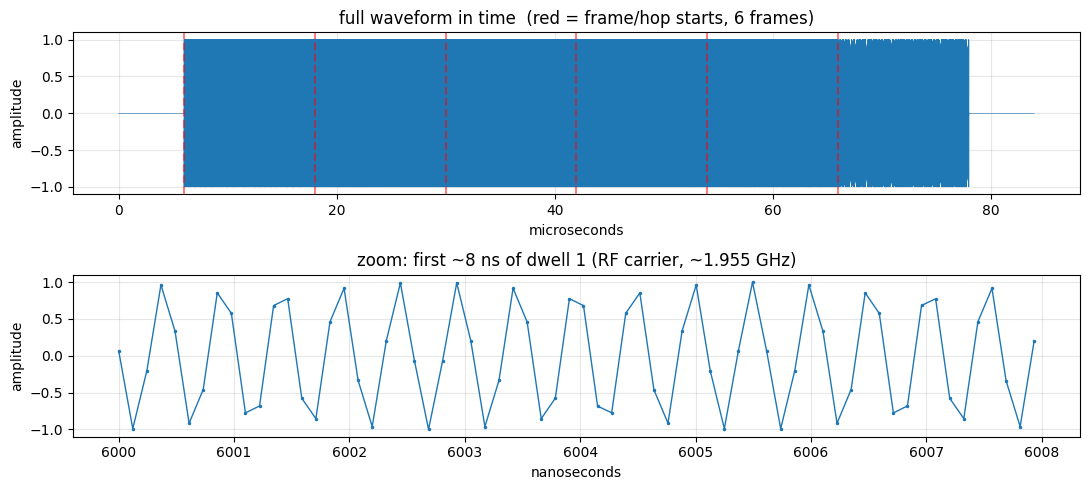

In [11]:
# time-domain view of the full generated waveform
t_us = np.arange(len(wave))/FS*1e6                        # time axis in microseconds
fig, ax = plt.subplots(2, 1, figsize=(11,5))             # two stacked panels

# (top) whole transmission: dead time at both ends + 6 contiguous frames
ax[0].plot(t_us, wave, lw=0.4)                           # the full real waveform
for s in starts:                                         # mark each frame (hop) start
    ax[0].axvline(s/FS*1e6, color='r', ls='--', alpha=0.5)
ax[0].set_title("full waveform in time  (red = frame/hop starts, %d frames)" % len(starts))
ax[0].set_xlabel("microseconds"); ax[0].set_ylabel("amplitude"); ax[0].grid(alpha=0.3)

# (bottom) zoom into ~8 ns at the start of dwell 1 to reveal the RF carrier sinusoid
a = starts[0]; b = a + int(round(8e-9*FS))               # first ~8 ns of dwell 1
ax[1].plot(t_us[a:b]*1e3, wave[a:b], marker='.', ms=3, lw=1.0)   # x in ns for readability
ax[1].set_title("zoom: first ~8 ns of dwell 1 (RF carrier, ~1.955 GHz)")
ax[1].set_xlabel("nanoseconds"); ax[1].set_ylabel("amplitude"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


<div dir="rtl" style="text-align:right">

## 8. التحقق النهائي: مطابقة المكتبة المرجعية

نتأكد أن مُرسِلنا يطابق `fhcpfsk.transmit` بالضبط (بنفس الـ seed والقنوات)،

</div>


In [12]:
wave_ref, info = fh.transmit(messages, channels=channels, seed=0,        # generate the reference from the lib
                             dead_before_us=6, dead_after_us=6, ramp_bits=0)  # same settings, no ramp
# compare the active part of the signal (same channels and frames)
same_len = min(len(wave), len(wave_ref))                # compare over the common length
err = np.max(np.abs(wave[:same_len] - wave_ref[:same_len]))  # largest absolute difference
print("max diff between our TX and reference =", f"{err:.2e}", "-> matches?", err < 1e-9)  # should be ~0


max diff between our TX and reference = 0.00e+00 -> matches? True


<div dir="rtl" style="text-align:right">

## 8.5 : تشوّهات المُرسِل (impairments)
المُرسِل المرجعي في `fhcpfsk.py` يوفّر مقبضين لمحاكاة لا-مثالية المُرسِل، وكلاهما **مضبوط على صفر** (مُرسِل مثالي)، تماماً كما في المُرسِل الأصلي `cpfsk_tx.m`:

- **`phase_tol`**: خطأ نسبي في الطور المتراكم لكل بِت (±180°)، أي مؤشّر تعديل فعّال `h = 1 ± phase_tol`.
- **`bit_tol`**: خطأ نسبي في دورة ساعة الرموز (symbol clock).
- **`*_mode`**: `'none'` (مثالي) | `'burst'`/`'hop'` (سحبة واحدة) | `'bit'` (سحبة لكل بِت).

عند القيم الافتراضية (صفر) يكون الخرج **مطابقاً تماماً** للنموذج المثالي المستخدم في كامل الكورس. ورفع `phase_tol` هو ما يجعل قمم طيف بعض القفزات تبدو أخفض (كما ناقشنا) رغم **تساوي قدرة كل قفزة**.

</div>


In [13]:
import inspect                                          # to read the function signature
sig = inspect.signature(fh.transmit)                    # signature of the reference transmit function
print("transmitter impairment defaults (ideal = 0):")   # the default impairment values
for k in ['phase_tol','phase_tol_mode','bit_tol','bit_tol_mode']:  # the four knobs
    print(f"  {k} = {sig.parameters[k].default!r}")     # print each default (zero = ideal)

# default output is identical to an explicit phase_tol=0 (ideal)
w_a, _ = fh.transmit(messages, channels=channels)                       # default output
w_b, _ = fh.transmit(messages, channels=channels, phase_tol=0.0, bit_tol=0.0)  # explicit zero
print("default == explicit-zero:", np.array_equal(w_a, w_b))           # should be identical

# switching an impairment on changes the signal (equal power, different spectrum)
w_imp, _ = fh.transmit(messages, channels=channels, phase_tol=0.10, phase_tol_mode='hop', seed=1)  # phase impairment
print("phase_tol=0.10 changes the waveform:", not np.array_equal(w_a, w_imp))  # shape changes, power doesn't


transmitter impairment defaults (ideal = 0):
  phase_tol = 0.0
  phase_tol_mode = 'none'
  bit_tol = 0.0
  bit_tol_mode = 'none'
default == explicit-zero: True
phase_tol=0.10 changes the waveform: True


<div dir="rtl" style="text-align:right">

## 9. الخلاصة

- بنينا **مُرسِلاً مرجعياً** كاملاً: نص → بِتات (MSB-first) → إطار (PREAMBLE/SFD/HDR/PAYLOAD/CRC) → موجة CPFSK → قفز ترددي.
- فهمنا **بنية الإطار** ووظيفة كل حقل، وفكرة **CRC** عموماً ثم نفّذنا **CRC-16/CCITT-FALSE** وتحققنا منه بمتّجه قياسي (`0x29B1`).
- قرأنا **مسار الطور** وعلاقته بانزياح التردد، وفهمنا لماذا **استمرارية الطور** ضرورية (لتقليل التسرّب الطيفي).
- طابقنا خرجنا مع `fhcpfsk` تماماً، فصار لدينا مصدر إشارات اختبار موثوق.

الآن ومعنا إشارة معروفة الإجابة، نبدأ بناء المستقبِل. أوّل مهمة: **اكتشاف القفزات وتحديد قنواتها** (المحاضرة 4).

</div>


<div dir="rtl" style="text-align:right">

---
### تمارين
1. غيّر رسالة واحدة بمقدار حرف واحد، وأعد حساب الـ CRC. كم بِتاً تغيّر في حقل الـ CRC؟
2. أرسل نفس الرسالة على قناتين مختلفتين وقارن الطيفين.
3. اقلب بِتاً واحداً في الـ PAYLOAD قبل حساب الـ CRC ثم بعده — لاحظ كيف يكتشف الـ CRC التغيير.

</div>
